In [1]:
# house_price_linear_regression.py

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# 1) Load dataset (replace with your CSV file)
df = pd.read_csv("house-prices.csv")  # must contain a 'price' column

# 2) Basic check
print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (128, 8)
   Home   Price  SqFt  Bedrooms  Bathrooms  Offers Brick Neighborhood
0     1  114300  1790         2          2       2    No         East
1     2  114200  2030         4          2       3    No         East
2     3  114800  1740         3          2       1    No         East
3     4   94700  1980         3          2       3    No         East
4     5  119800  2130         3          3       3    No         East


In [2]:
# To see the statistical parameters
df.describe()

,Home,Price,SqFt,Bedrooms,Bathrooms,Offers
count,128.000000,128.000000,128.000000,128.000000,128.000000,128.000000
mean,64.500000,130427.343750,2000.937500,3.023438,2.445312,2.578125
std,37.094474,26868.770371,211.572431,0.725951,0.514492,1.069324
min,1.000000,69100.000000,1450.000000,2.000000,2.000000,1.000000
25%,32.750000,111325.000000,1880.000000,3.000000,2.000000,2.000000
50%,64.500000,125950.000000,2000.000000,3.000000,2.000000,3.000000
75%,96.250000,148250.000000,2140.000000,3.000000,3.000000,3.000000
max,128.000000,211200.000000,2590.000000,5.000000,4.000000,6.000000


In [3]:
# To see the datatypes and info of the dataset
print(df.info())
print(df.dtypes)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128 entries, 0 to 127
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Home          128 non-null    int64 
 1   Price         128 non-null    int64 
 2   SqFt          128 non-null    int64 
 3   Bedrooms      128 non-null    int64 
 4   Bathrooms     128 non-null    int64 
 5   Offers        128 non-null    int64 
 6   Brick         128 non-null    object
 7   Neighborhood  128 non-null    object
dtypes: int64(6), object(2)
memory usage: 8.1+ KB
None
Home             int64
Price            int64
SqFt             int64
Bedrooms         int64
Bathrooms        int64
Offers           int64
Brick           object
Neighborhood    object
dtype: object


In [5]:
# Preprocess the dataset(label encoding)
for col in df.columns:
    if df[col].dtype == 'object':
        encoder = LabelEncoder()
        df[col] = encoder.fit_transform(df[col])

In [6]:
# Extract the independent and dependent features 
X = df.drop(columns=['Price'])
y = df['Price']

# Split the dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Preprocess the dataset(Standardization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

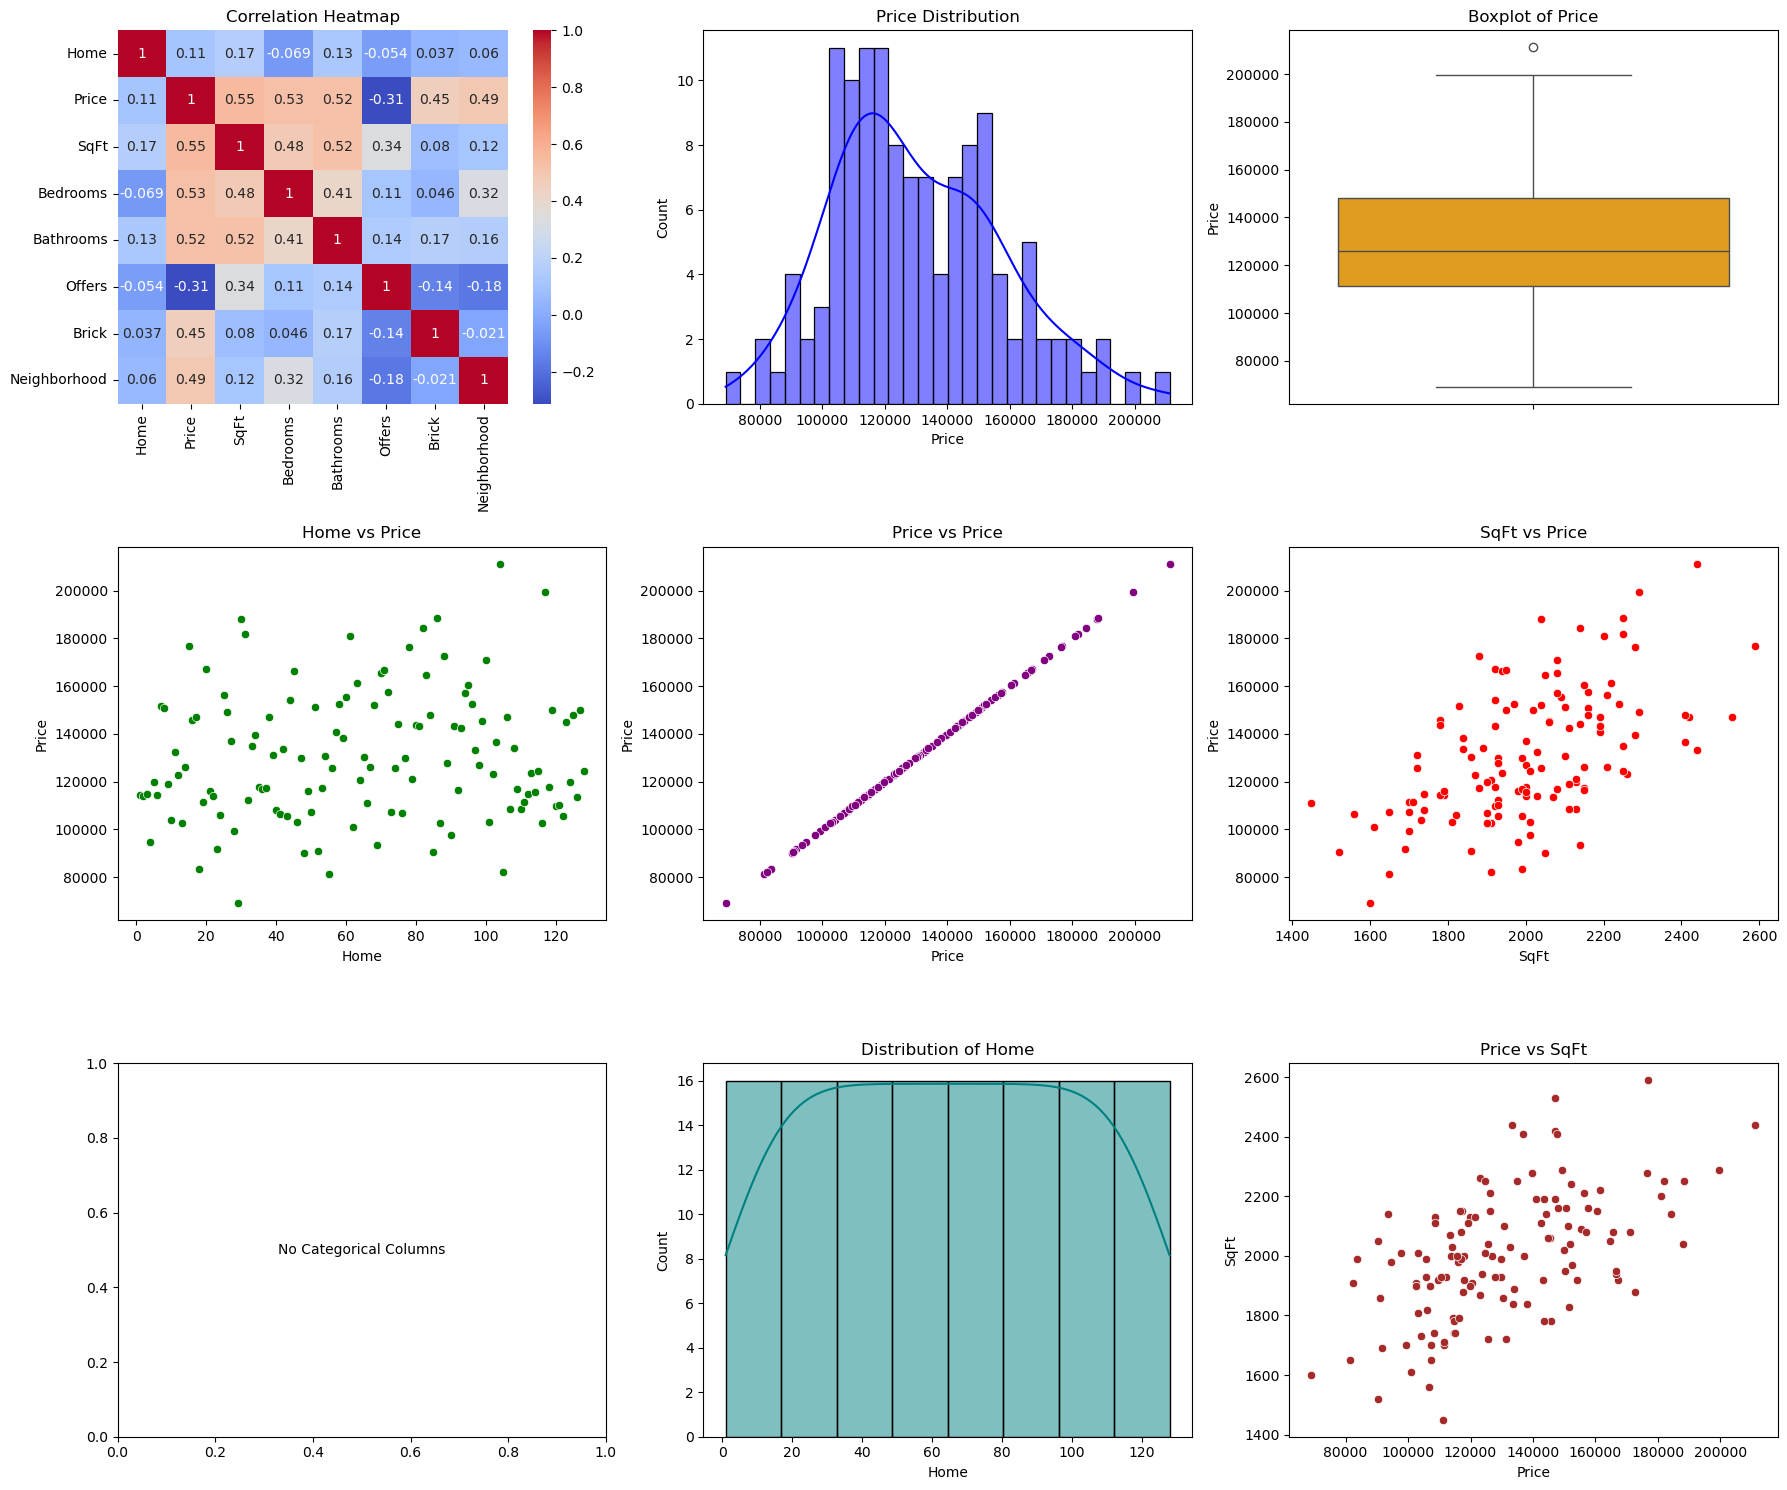

In [10]:
# 3) Data Visualization
plt.figure(figsize=(18, 15))

# Correlation Heatmap
plt.subplot(3, 3, 1)
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")

# Price Distribution
plt.subplot(3, 3, 2)
sns.histplot(df['Price'], bins=30, kde=True, color='blue')
plt.title("Price Distribution")

# Boxplot for Price
plt.subplot(3, 3, 3)
sns.boxplot(y=df['Price'], color='orange')
plt.title("Boxplot of Price")

# Pairplot for first 4 numeric columns
plt.subplot(3, 3, 4)
sns.scatterplot(x=df[df.columns[0]], y=df['Price'], color='green')
plt.title(f"{df.columns[0]} vs Price")

# Second feature vs Price
plt.subplot(3, 3, 5)
sns.scatterplot(x=df[df.columns[1]], y=df['Price'], color='purple')
plt.title(f"{df.columns[1]} vs Price")

# Third feature vs Price
plt.subplot(3, 3, 6)
sns.scatterplot(x=df[df.columns[2]], y=df['Price'], color='red')
plt.title(f"{df.columns[2]} vs Price")

# Countplot of Categorical Feature (if available)
plt.subplot(3, 3, 7)
cat_cols = df.select_dtypes(include='object').columns
if len(cat_cols) > 0:
    sns.countplot(x=cat_cols[0], data=df, palette='Set2')
    plt.title(f"Countplot of {cat_cols[0]}")
    plt.xticks(rotation=45)
else:
    plt.text(0.5, 0.5, 'No Categorical Columns', ha='center', va='center')

# Distribution of Numeric Feature
plt.subplot(3, 3, 8)
num_cols = df.select_dtypes(include=np.number).columns
sns.histplot(df[num_cols[0]], kde=True, color='teal')
plt.title(f"Distribution of {num_cols[0]}")

# Pairwise Relationship Plot (Sample)
plt.subplot(3, 3, 9)
sns.scatterplot(x=df[num_cols[1]], y=df[num_cols[2]], color='brown')
plt.title(f"{num_cols[1]} vs {num_cols[2]}")

plt.tight_layout()
plt.show()

In [13]:
# Apply the mode
model = LinearRegression()
model.fit(X_train, y_train)

# Predict the model 
y_pred = model.predict(X_test)

In [14]:
# Metrics that to be calculated
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
recall = r2_score(y_test, y_pred)

print("Mean Squared Error : ", np.round(mse, 2))
print("Mean Absolute Error : ", np.round(mae, 2))
print("Recall Score : ", np.round(recall, 2))

Mean Squared Error :  130338013.25
Mean Absolute Error :  9499.97
Recall Score :  0.78


C:\Users\Vaka Bela Jithendra\AppData\Local\Temp\ipykernel_17592\1729282427.py:17: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




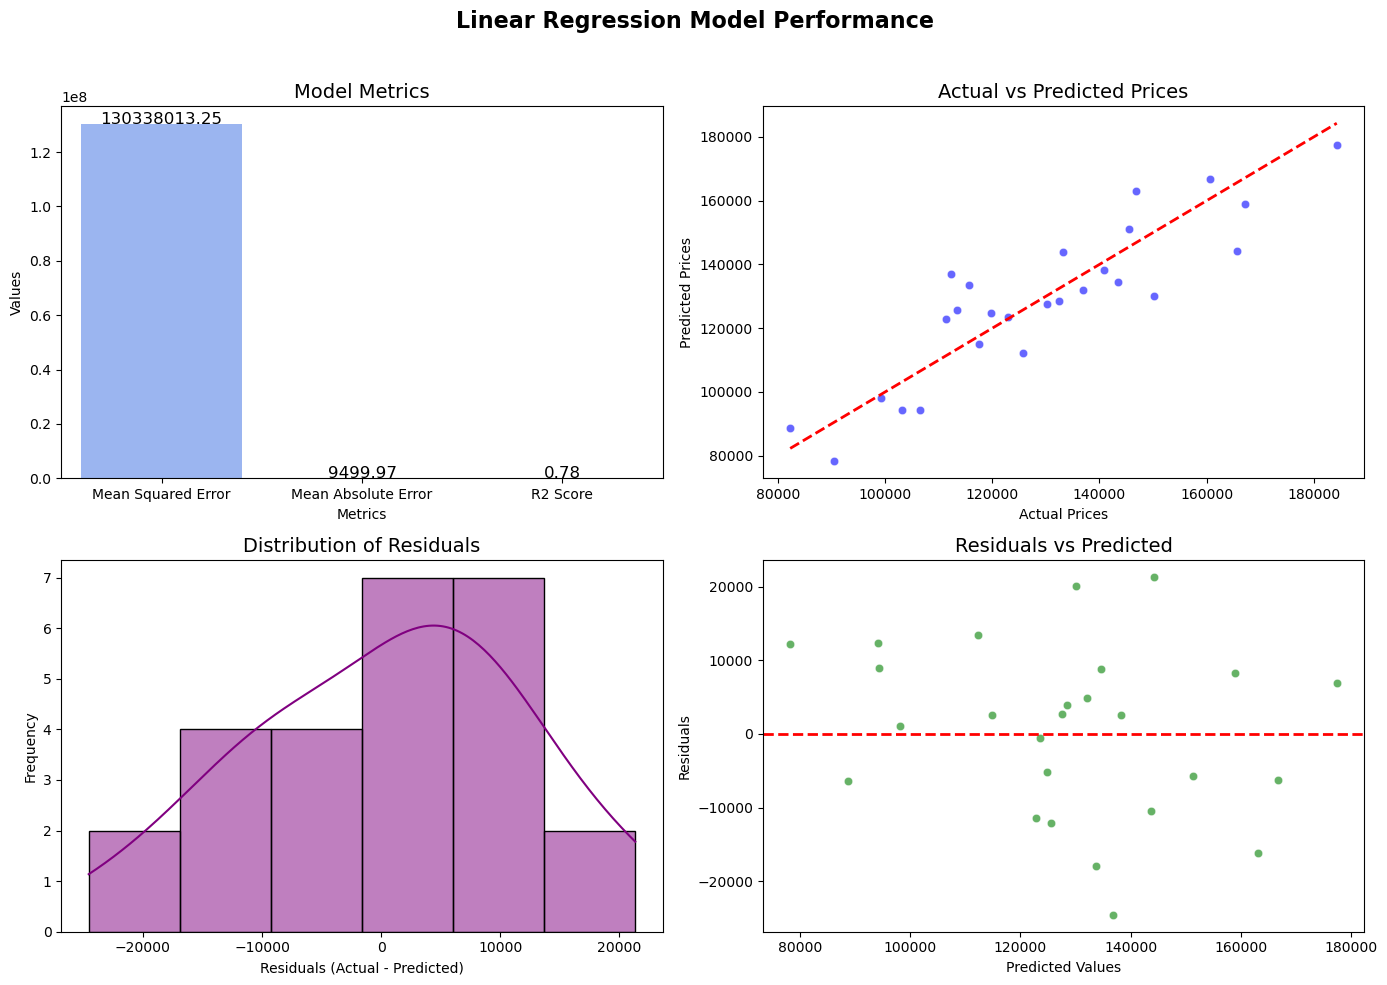

In [18]:
# 9) Visualization of model performance in subplots
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare metric data
metrics = ['Mean Squared Error', 'Mean Absolute Error', 'R2 Score']
values = [mse, mae, recall]

# Compute residuals
residuals = y_test - y_pred

# Create 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Linear Regression Model Performance", fontsize=16, fontweight='bold')

# Plot 1 — Metrics Bar Plot
sns.barplot(x=metrics, y=values, palette="coolwarm", ax=axes[0, 0])
axes[0, 0].set_title("Model Metrics", fontsize=14)
axes[0, 0].set_xlabel("Metrics")
axes[0, 0].set_ylabel("Values")
for i, v in enumerate(values):
    axes[0, 0].text(i, v + 0.01, f"{v:.2f}", ha='center', fontsize=12)

# Plot 2 — Actual vs Predicted
sns.scatterplot(x=y_test, y=y_pred, color='blue', alpha=0.6, ax=axes[0, 1])
axes[0, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
                color='red', linestyle='--', linewidth=2)
axes[0, 1].set_title("Actual vs Predicted Prices", fontsize=14)
axes[0, 1].set_xlabel("Actual Prices")
axes[0, 1].set_ylabel("Predicted Prices")

# Plot 3 — Residuals Distribution
sns.histplot(residuals, kde=True, color='purple', ax=axes[1, 0])
axes[1, 0].set_title("Distribution of Residuals", fontsize=14)
axes[1, 0].set_xlabel("Residuals (Actual - Predicted)")
axes[1, 0].set_ylabel("Frequency")

# Plot 4 — Residuals vs Predicted
sns.scatterplot(x=y_pred, y=residuals, alpha=0.6, color='green', ax=axes[1, 1])
axes[1, 1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1, 1].set_title("Residuals vs Predicted", fontsize=14)
axes[1, 1].set_xlabel("Predicted Values")
axes[1, 1].set_ylabel("Residuals")

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [30]:
# 10) Save the trained model and dataset path
import joblib
import os

# Define save paths
model_path = "saved_models/house_price_model.pkl"
dataset_info_path = "saved_models/dataset_path.txt"

# Create folder if not exists
os.makedirs("saved_models", exist_ok=True)

# Save the model
joblib.dump(model, model_path)
print(f"\n✅ Model saved successfully at: {model_path}")

# Save dataset path
with open(dataset_info_path, "w") as f:
    f.write("Dataset used: house-prices.csv\n")
print(f"✅ Dataset path stored at: {dataset_info_path}")


✅ Model saved successfully at: saved_models/house_price_model.pkl
✅ Dataset path stored at: saved_models/dataset_path.txt


In [32]:
df.columns

Index(['Home', 'Price', 'SqFt', 'Bedrooms', 'Bathrooms', 'Offers', 'Brick',
       'Neighborhood'],
      dtype='object')

In [36]:
import joblib

# Load model
model = joblib.load("saved_models/house_price_model.pkl")
print("✅ Model loaded successfully!")

# New data
new_data = np.array([[3, 2100, 2, 3, 3, 2, 1]])

# Make predictions
y_pred_new = model.predict(new_data)
y_pred_new

✅ Model loaded successfully!


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



array([164443.44096786])